<a href="https://colab.research.google.com/github/b-karapet/colab-notebooks/blob/main/Brute_Force_with_ORB_(binary)_descriptors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

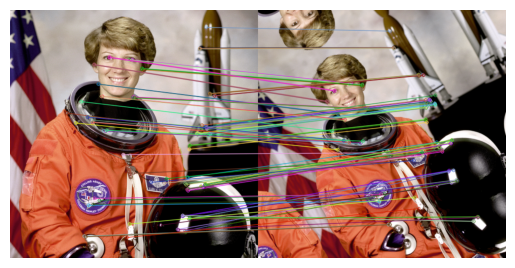

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sift = cv2.SIFT_create()

img1 = cv2.imread("sample_data/img1.png")
img2 = cv2.imread("sample_data/img2.png")

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

n = 100

img3 = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:n],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))   # convert BGR to RGB for display
plt.axis("off")
plt.show()